In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 读取CSV文件
df = pd.read_csv('151676_pca_original_logtransform.csv', index_col=0)

# 获取前10列
data_10cols = df.iloc[:, 2:12]

print(f"读取的数据形状: {data_10cols.shape}")
print(f"列名: {data_10cols.columns.tolist()}")
print("\n前几行数据:")
print(data_10cols.head())

读取的数据形状: (3460, 10)
列名: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']

前几行数据:
                         PC_1      PC_2      PC_3      PC_4      PC_5  \
AAACAAGTATCTCCCA-1  -1.772127  0.449687  0.061165  0.237428 -0.921886   
AAACAATCTACTAGCA-1  -2.471853 -1.028684 -0.343278  0.107971  0.804449   
AAACACCAATAACTGC-1  10.403121  1.687472 -0.535298  0.771619 -1.633401   
AAACAGAGCGACTCCT-1  -2.938804  0.108890 -0.482090  0.411884 -0.368659   
AAACAGGGTCTATATT-1   1.878489  0.095544  1.303807 -0.259599 -0.001267   

                        PC_6      PC_7      PC_8      PC_9     PC_10  
AAACAAGTATCTCCCA-1 -1.321663 -0.454995 -0.373809  0.524781 -0.269919  
AAACAATCTACTAGCA-1  0.277814  0.671514  1.465584  0.900420 -0.412563  
AAACACCAATAACTGC-1 -1.324518 -0.219969 -0.045219 -0.098311 -0.328856  
AAACAGAGCGACTCCT-1  0.631487 -1.100148 -0.400539  0.193605  0.707637  
AAACAGGGTCTATATT-1 -0.617629 -1.186303 -0.707707  0.101322  0.330681  


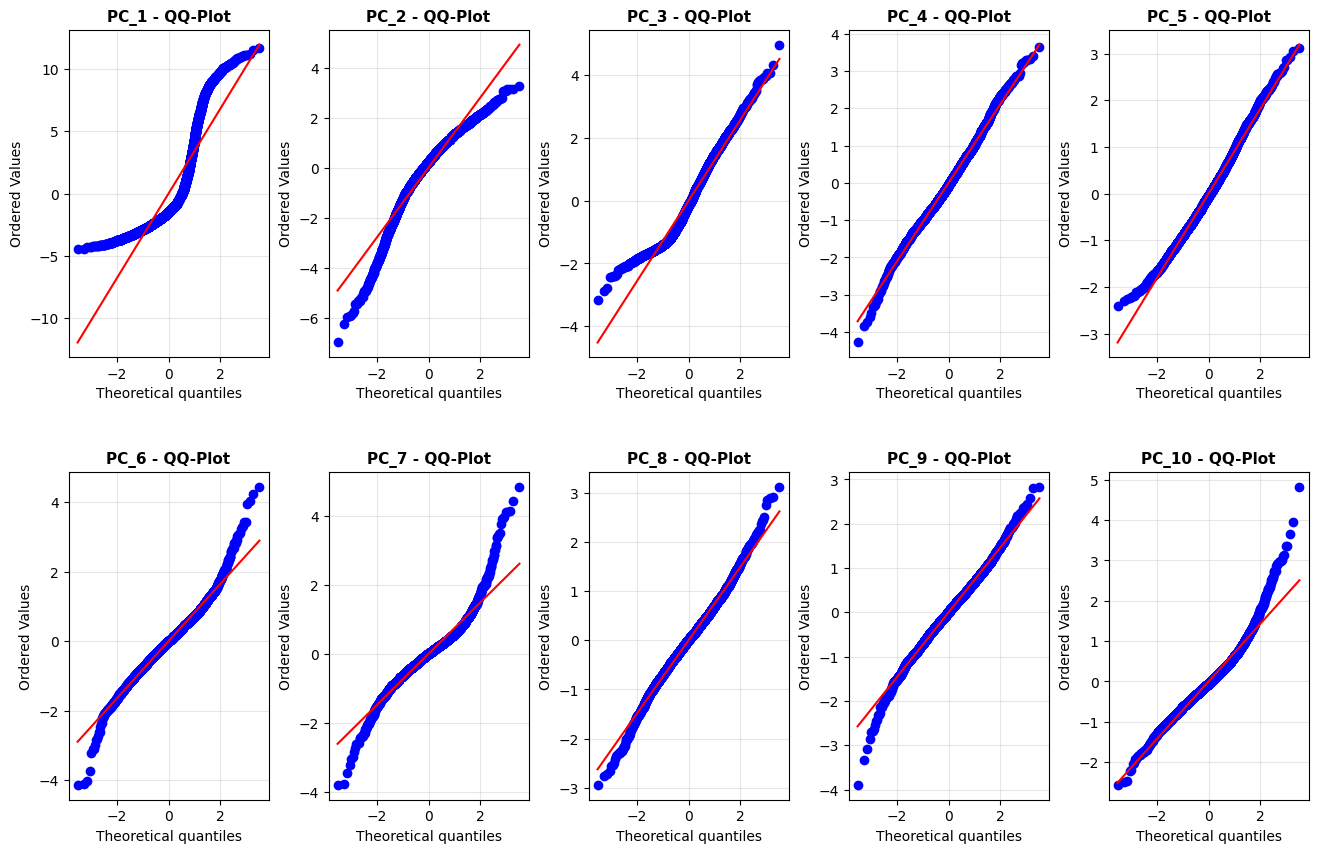

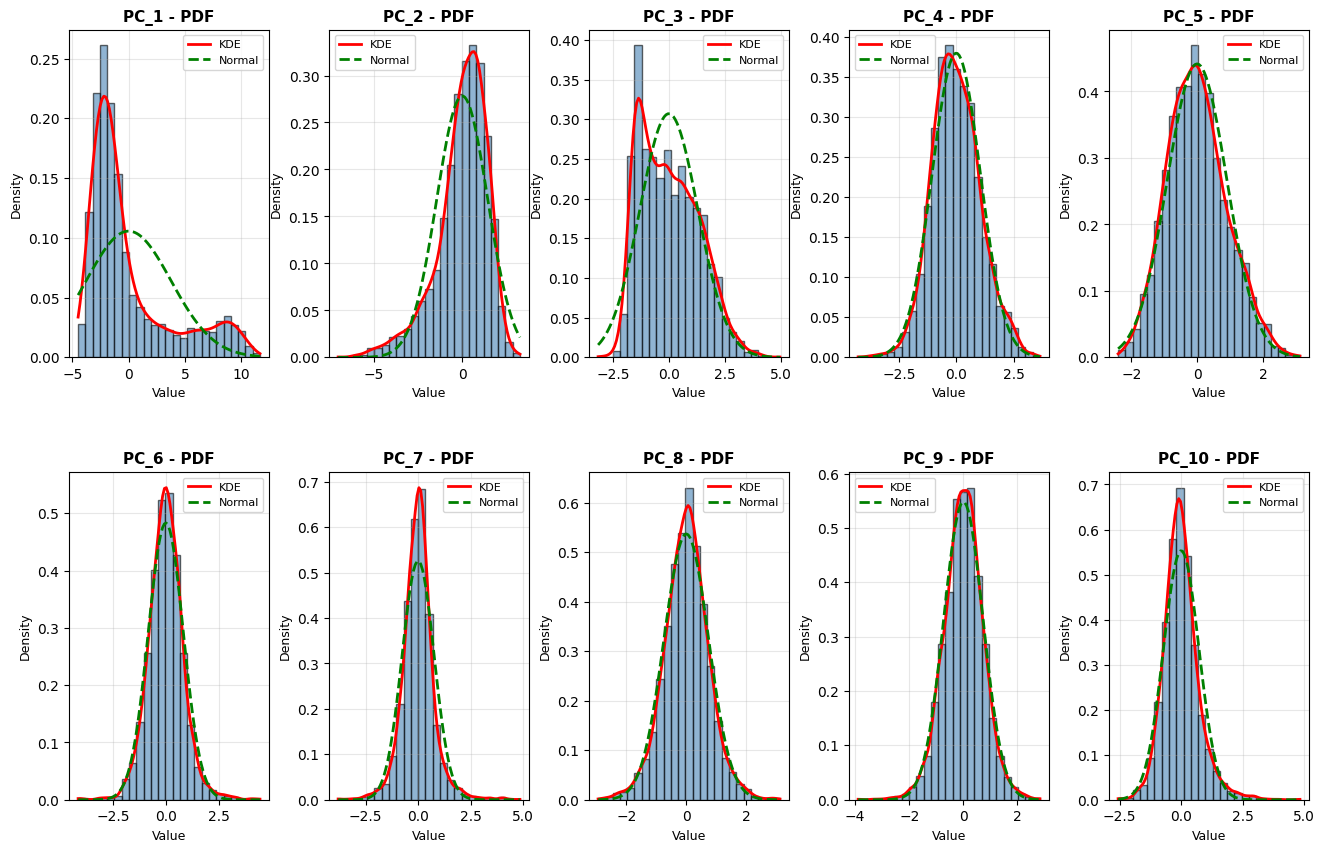

QQ-Plot和概率密度分布图绘制完成（分开两个框）！


In [22]:
# 绘制QQ-Plot和概率密度分布图（分开两个图表框）
from scipy import stats

# ===== 第一个框：QQ-Plot（2行×5列）=====
fig1 = plt.figure(figsize=(16, 10))
gs1 = fig1.add_gridspec(2, 5, hspace=0.35, wspace=0.3)

for idx, col in enumerate(data_10cols.columns):
    data = data_10cols[col].values
    row = idx // 5
    col_idx = idx % 5
    
    ax_qq = fig1.add_subplot(gs1[row, col_idx])
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{col} - QQ-Plot', fontsize=11, fontweight='bold')
    ax_qq.grid(True, alpha=0.3)

plt.show()

# ===== 第二个框：概率密度分布图（2行×5列）=====
fig2 = plt.figure(figsize=(16, 10))
gs2 = fig2.add_gridspec(2, 5, hspace=0.35, wspace=0.3)

for idx, col in enumerate(data_10cols.columns):
    data = data_10cols[col].values
    row = idx // 5
    col_idx = idx % 5
    
    ax_pdf = fig2.add_subplot(gs2[row, col_idx])
    
    # 绘制直方图（正规化为概率密度）
    ax_pdf.hist(data, bins=25, density=True, alpha=0.6, color='steelblue', edgecolor='black')
    
    # 绘制KDE曲线（核密度估计）
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 100)
    ax_pdf.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    
    # 绘制正态分布曲线进行对比
    mu, sigma = data.mean(), data.std()
    x_normal = np.linspace(data.min(), data.max(), 100)
    ax_pdf.plot(x_normal, stats.norm.pdf(x_normal, mu, sigma), 'g--', linewidth=2, label='Normal')
    
    ax_pdf.set_title(f'{col} - PDF', fontsize=11, fontweight='bold')
    ax_pdf.set_xlabel('Value', fontsize=9)
    ax_pdf.set_ylabel('Density', fontsize=9)
    ax_pdf.legend(fontsize=8, loc='best')
    ax_pdf.grid(True, alpha=0.3)

plt.show()

print("QQ-Plot和概率密度分布图绘制完成（分开两个框）！")